# Running your first Simulation

Now that we know how to create a `Grid` and a `State`, let's see how to advance that state in time. To do this, we use the `Solver` class.

## 1. Setup

Let's recreate our grid and state from the previous tutorial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from saetass.grid import Grid
from saetass.state import State
from saetass.solver import Solver

# Create a spatial grid
grid = Grid.uniform(r_min=0.0, r_max=10.0, num_r_cells=100, t_min=0, t_max=1.0, num_timesteps=100)

# Create an initial state: a localized burst at the center
r = grid.r_centers
state = State(f=np.exp(-(r - 5.0)**2 / (2 * 0.2**2)))

## 2. Configuring the Solver

The `Solver` needs to know:
1. Which physical processes to solve (**problem_type**).
2. The parameters for those processes (**operator_params**).

Let's simulate a simple **Diffusion** problem.

In [2]:
# Define the problem: only diffusion
problem_type = "diffusion"

# Set a constant diffusion coefficient
# D_values must match the grid shape (num_cells_r,)
D_const = 1.0
D_values = np.full(grid.num_cells_r, D_const)

operator_params = {
    "diffusion": {"D_values": D_values} 
}

# Instantiate the solver
solver = Solver(
    grid=grid, 
    state=state, 
    problem_type=problem_type,
    operator_params=operator_params
)

╭─ SAETASS: Solver for Astroparticle Equation of Transport Analysis in Spherical Symmetry ─╮              
              │                                                                                          │              
              │                                     :::::::::::::::                                      │              
              │                                 :::::::::::::::::::::::                                  │              
              │                               :::::::::++++++++++::::::::                                │              
              │                              ::::::::++++++++++++++::::::::                              │              
              │                             :::::::++++++++++++++++++:::::::                             │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                            :::::::++++++++++++++++++++:::::::                            │              
              │                            :::::::+++++++++++++++++++::::::::                            │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                             ::::::::::++++++++++++++                                     │              
              │                              :::::::::::::::++++++                                       │              
              │                                :::::::::::::::::::::                                     │              
              │                                   ::::::::::::::::::::::                                 │              
              │                                       ++:::::::::::::::::::                              │              
              │                                     ++++++++++++::::::::::::                             │              
              │                                   ++++++++++++++++++:::::::::                            │              
              │                           ::::::::++++++++++++++++++++::::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                            :::::::++++++++++++++++++++:::::[

## 3. Advancing in Time

SAETASS allows you to run simulations in two ways:
- `solver.run()`: Runs the entire simulation until `t_max`.
- `solver.step(n)`: Advances by `n` time steps.

Let's use `step()` to see the evolution progressively.

Output()

Output()

Output()

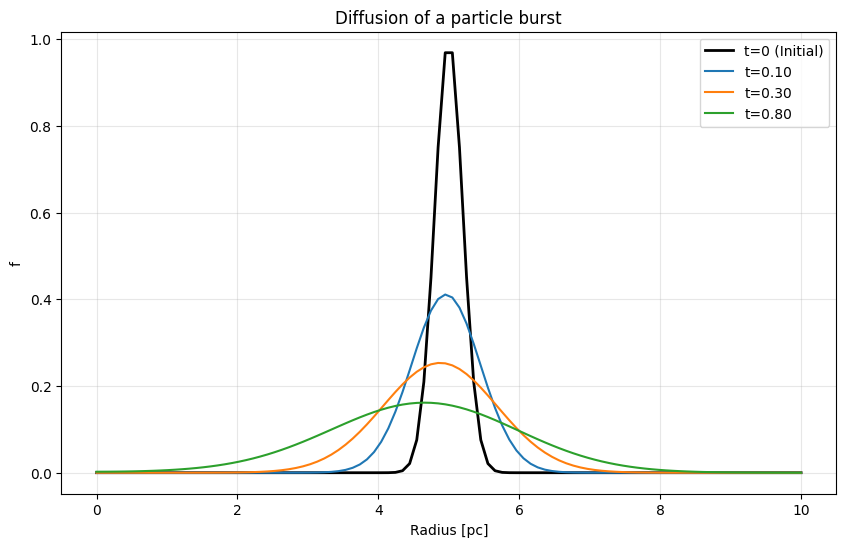

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(grid.r_centers, state.get_f(), label='t=0 (Initial)', lw=2, color='black')

# Run for some steps and plot intermediate results
for steps in [10, 20, 50]:
    solver.step(steps)
    plt.plot(grid.r_centers, state.get_f(), label=f't={state.t:.2f}')

plt.xlabel('Radius [pc]')
plt.ylabel('f')
plt.title('Diffusion of a particle burst')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Why does this happen?

As we can see, the initial narrow spike spreads out over time. This is exactly what the Diffusion operator does: it smooths out gradients in the distribution function. 

Notice how the **area under the curve** is conserved? SAETASS uses a Finite Volume approach to ensure that particles are not lost during transport.

## Summary

In this tutorial, you learned:
1. How to define a **problem type**.
2. How to pass **parameters** to specific operators.
3. How to **advance** the simulation using `step()`.

In the next tutorial, we will explore more complex physics like combined **Advection-Diffusion** and adding a **Source**!